## **CAPSTONE MODUL 3 YOSEF IVANDER**

## **Efektivitas Kampanye Marketing Bank**

**Project Overview**

Proyek ini bertujuan menganalisis efektivitas kampanye marketing bank dalam menawarkan produk deposito kepada nasabah, dengan fokus pada pengaruh kepemilikan pinjaman seperti housing loan dan personal loan terhadap keputusan nasabah membuka deposito.

Melalui pendekatan machine learning classification, proyek ini akan mengidentifikasi faktor-faktor yang memengaruhi respons nasabah terhadap kampanye serta membantu bank meningkatkan strategi targeting marketing agar lebih efektif, efisien, dan berbasis data.

**Business Understanding**

**Background**

Persaingan industri perbankan semakin ketat sehingga bank perlu strategi pemasaran yang tepat untuk meningkatkan produk simpanan seperti deposito.

Namun, tidak semua nasabah merespons kampanye marketing dengan baik. Salah satu faktor yang diduga memengaruhi respons nasabah adalah kondisi finansial mereka, khususnya kepemilikan pinjaman seperti kredit rumah atau pinjaman pribadi.

Tanpa analisis data yang tepat, kampanye marketing berisiko:

*   Tidak tepat sasaran
*   Biaya marketing tinggi
*   Tingkat konversi rendah

**Business Problem**

Beberapa permasalahan bisnis yang ingin diselesaikan :
1. Apakah nasabah yang memiliki pinjaman cenderung menolak penawaran deposito?
2. Faktor apa saja yang paling mempengaruhi keberhasilan kampanye marketing bank?
3. Bagaimana bank dapat mengoptimalkan strategi targeting agar kampanye lebih efektif?
4. Bagaimana mengurangi biaya marketin tapa menurunkan tingkat konversi nasabah?

**Stakeholders**

1. **Marketing Team Bank** : Menjalankan kampanye promosi produk bank.
2. **Data Analyst / Data Scientist** : Memberikan insight berbasis data dengan menggunakan model.
3. **Manajemen Bank (Desicion Maker)** : Menentukan kebijakan marketing.
4. **Nasabah Bank** : Target kampanye marketing.

# **Project Objectives**


*   Menganalisis faktor yang mempengaruhi keberhasilan kampanye.
*   Mengidentifikasi pengaruh kepemilikan pinjaman terhadap keputusan nasabah.
*   Mengembangkan model classification untuk prediksi respons nasabah
*   Memberikan rekomendasi strategi marketing berbasis data.





**Spesific Objectives**


*   Melakukan eksplorasi data nasabah bank.
*   Menganalisis hubungan variabel loan dengan respons deposito.
*   Membangun model machine learning classification.
*   Mengevaluasi performa model menggunakan metrik classification.
*   Mengidentifikasi variabel paling berpengaruh.
*   Memberikan insight actionable untuk marketing bank.

# **Business Impact Analysis (Confusion Matrix)**

**Peran Confusion Matrix dalam Bisnis**

Confusion matrix membantu mengevaluasi performa model calssification dalam memprediksi apakah nasabah akan membuka deposito atau tidak.

Dengan memahami hasil prediksi model, bank dapat menentukan strategi marketing yang lebih efektif dan mengurangi biaya kampanye yang tidak tepat sasaran.

Actual / Predicted	    Prediksi Ya (Deposit)	         Prediksi Tidak
Actual Ya	              True Positive (TP)	           False Negative (FN)
Actual Tidak	          False Positive (FP)	         True Negative (TN)

# Import Library

* Pandas : manipulasi data
* Numpy : operasi numerik
* Matplotlib : visualisasi dasar
* Seaborn : visualisasi statistik yang lebih informatif
* Sklearn : Preprocessing dan machine learning

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split

# Prepocessing tools
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('data_bank_marketing_campaign.csv')

df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


# Data Understanding
Tujuan pada tahap ini yaitu untuk memahami kondisi awal data sebelum dibersihkan.

df.info()
* Cek jumlah data
* Cek tipe data (numerik/kategorikal)

df.describe()
* Statistik numerik (mean, min, max)
* Deteksi nilai ekstrem

df.isnul().sum()
* Cek missing values

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


,0
age,0
job,0
balance,0
housing,0
loan,0
contact,0
month,0
campaign,0
pdays,0
poutcome,0


# Age Binning

In [4]:
bins = [0, 30, 40, 55, 100]
labels = ["Young", "Adult", "Middle_Age", "Senior"]

df["age_category"] = pd.cut(df["age"], bins=bins, labels=labels)

df[["age", "age_category"]].head()

,age,age_category
0,55,Middle_Age
1,39,Adult
2,51,Middle_Age
3,38,Adult
4,36,Adult


In [5]:
df["age_category"].value_counts()

,count
age_category,
Adult,2959
Middle_Age,2409
Young,1391
Senior,1054


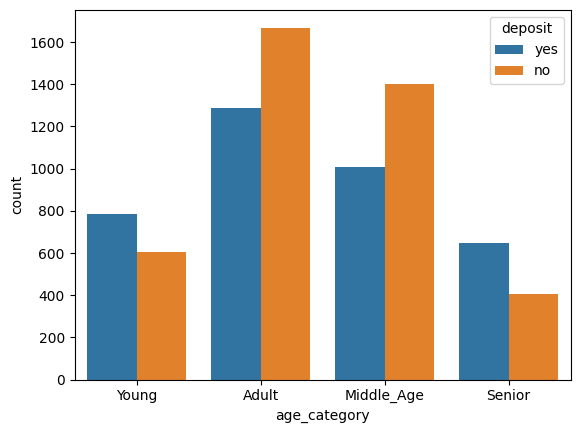

In [6]:
sns.countplot(x="age_category", hue="deposit", data=df)
plt.show()

In [7]:
age_pct = df["age_category"].value_counts(normalize=True) * 100

age_pct

,proportion
age_category,
Adult,37.872776
Middle_Age,30.833227
Young,17.803661
Senior,13.490337


# Data Cleansing
* Median lebih aman dari outlier
* Modus menjaga distribusi kategori

## Missing Values

In [8]:
# Numerik -> median
for col in df.select_dtypes(include='number').columns:
  df[col] = df[col].fillna(df[col].median())

# Kategorikal -> modus
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna(df[col].mode()[0])

## Menghapus Duplikasi

In [9]:
df.drop_duplicates(inplace=True)

## Standarisasi Huruf

Untuk merubah kategorikal seperti:
* "Yes"
* "yes "
* "YES"

dengan tujuan agar encoding tidak salah.

# Exploratory Data Analysis (EDA)
Tujuannya untuk melihat hubungan loan dan deposit secara visual sebelum modeling.

## Distribusi Target

Untuk melihat apakah data seimbang, jika tidak seimbang perlu perhatian saat modeling.

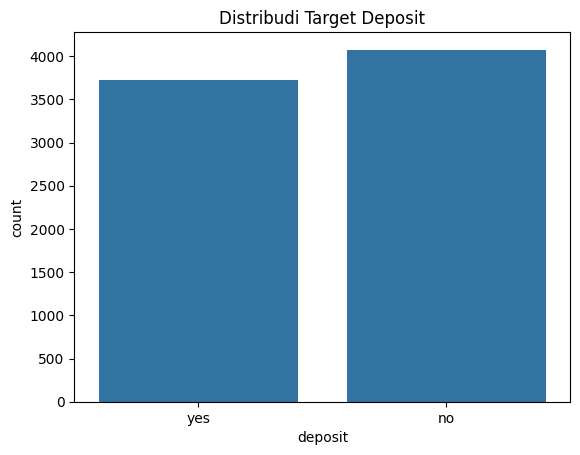

In [10]:
sns.countplot(x='deposit', data=df)
plt.title("Distribudi Target Deposit")
plt.show()

Grafik menunjukkan jumlah nasabah berdasarkan status deposit (yes dan no).

Terlihat bahwa jumlah nasabah yang tidak melakukan deposit (no) lebih banyak dibandingkan dengan yang melakukan deposit (yes).

Artinya:

Dataset memiliki sedikit ketidakseimbangan kelas (class imbalance).

Model prediksi perlu memperhatikan metrik seperti Recall dan ROC-AUC, bukan hanya Accuracy.

Secara bisnis, conversion rate masih relatif rendah sehingga penting menggunakan model untuk menargetkan nasabah yang lebih potensial.

### Housing vs Deposit

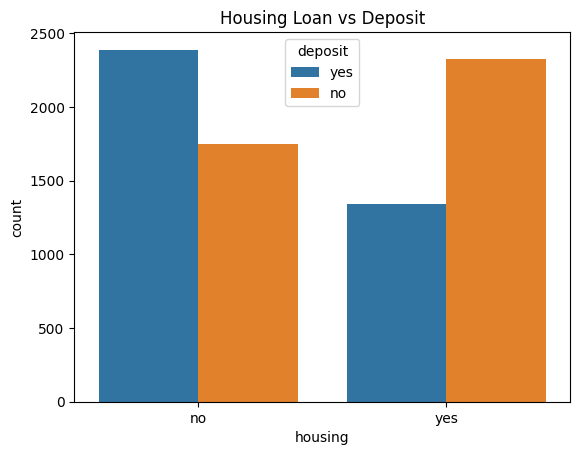

In [11]:
sns.countplot(x='housing', hue='deposit', data=df)
plt.title("Housing Loan vs Deposit")
plt.show()

Grafik menunjukkan hubungan antara kepemilikan housing loan dengan keputusan nasabah untuk melakukan deposit.

Terlihat bahwa:

Nasabah yang tidak memiliki housing loan (no) memiliki jumlah deposit (yes) yang lebih tinggi dibandingkan yang memiliki housing loan.

Nasabah yang memiliki housing loan (yes) cenderung lebih banyak tidak melakukan deposit (no).

Insight Bisnis:

Nasabah yang memiliki cicilan rumah kemungkinan memiliki beban finansial lebih besar, sehingga:

Lebih kecil kemungkinannya untuk menempatkan dana pada deposito.

Cenderung lebih berhati-hati dalam mengalokasikan dana.

In [12]:
df['housing'].value_counts()

,count
housing,
no,4136
yes,3669


In [13]:
housing_pct = df['housing'].value_counts(normalize=True) * 100

housing_pct

,proportion
housing,
no,52.991672
yes,47.008328


### Loan vs Deposit

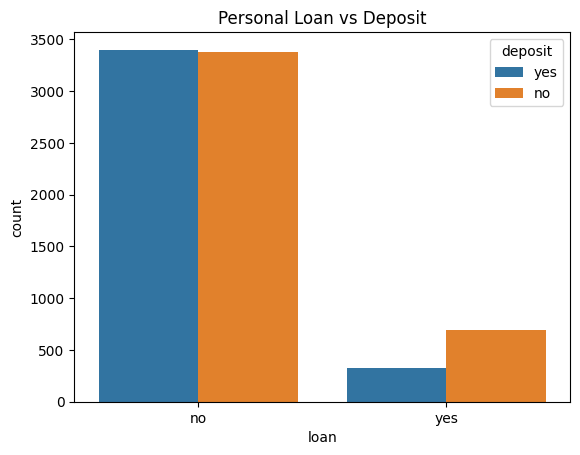

In [14]:
sns.countplot(x='loan', hue='deposit', data=df)
plt.title("Personal Loan vs Deposit")
plt.show()

Grafik menunjukkan hubungan antara kepemilikan personal loan dengan keputusan nasabah untuk melakukan deposit.

Terlihat bahwa:

Mayoritas nasabah tidak memiliki personal loan (no).

Pada kelompok yang memiliki personal loan (yes), jumlah yang tidak deposit (no) lebih besar dibandingkan yang deposit.

Namun secara umum, perbedaan pengaruh personal loan terhadap deposit tidak sekuat housing loan.

Insight Analisis

Nasabah yang memiliki personal loan cenderung:

Memiliki kewajiban finansial tambahan

Lebih berhati-hati dalam mengalokasikan dana ke deposito

Namun karena jumlah pemilik personal loan relatif kecil dibandingkan non-loan, variabel ini kemungkinan tidak menjadi faktor utama dalam keputusan deposit.

In [15]:
df["loan"].value_counts(normalize=True) * 100

,proportion
loan,
no,86.880205
yes,13.119795


# Encoding

Untuk merubah data kategori(text) menjadi numerik(0 dan 1)

In [16]:
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})
df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
df['loan'] = df['loan'].map({'yes': 1, 'no': 0})

In [17]:
df = pd.get_dummies(df, drop_first=True)

Untuk merubah beberapa kolom kategorikal menjadi kolom baru(dummy variables), agar model bisa membaca semua variabel.

# Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

x = df.drop('deposit', axis=1)
y = df['deposit']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
model = LogisticRegression(max_iter=5000)

# Evaluasi Model (Random Forest)

In [23]:
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print('Confusion Matrix (Random Forest)')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print('ROC AUC:', roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]))

Confusion Matrix (Random Forest)
[[624 191]
 [273 473]]
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       815
           1       0.71      0.63      0.67       746

    accuracy                           0.70      1561
   macro avg       0.70      0.70      0.70      1561
weighted avg       0.70      0.70      0.70      1561

ROC AUC: 0.7590832086054047


# Feature Importance (Random Forest)

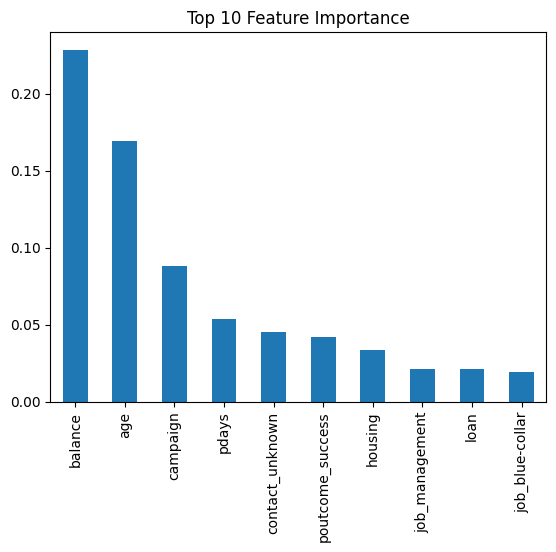

In [26]:
importances = pd.Series(rf_model.feature_importances_, index=x.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Feature Importance')
plt.show()

Grafik menunjukkan 10 variabel yang paling berpengaruh dalam memprediksi apakah nasabah akan melakukan deposit berdasarkan model Random Forest.

Terlihat bahwa:

balance - paling berpengaruh

age - faktor signifikan

campaign - jumlah kontak campaign

pdays - jarak hari dari campaign sebelumnya

contact_unknown

poutcome_success

housing

job_management

loan

job_blue-collar

1. Balance adalah faktor paling
dominan

Nasabah dengan saldo lebih tinggi cenderung:

- Memiliki kemampuan finansial lebih baik

- Lebih siap untuk menempatkan dana dalam deposito

2. Age juga berpengaruh besar

Artinya:

Segmentasi usia penting dalam campaign

Mungkin usia tertentu lebih tertarik pada deposito

3. Faktor Campaign dan Pdays penting

Ini menunjukkan:

Strategi marketing sebelumnya berpengaruh

Timing follow-up campaign sangat krusial

In [24]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].str.lower().str.strip()

In [27]:
df['deposit'].value_counts(normalize=True)

,proportion
deposit,
0,0.522101
1,0.477899
